# Packages Installation

In [19]:
!pip uninstall numpy -y
!pip install "numpy<2"

You can safely remove it manually.
You can safely remove it manually.


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
^C



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached numpy-1.26.4-cp39-cp39-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp39-cp39-win_amd64.whl (15.8 MB)


In [ ]:
!pip install wfdb pandas scikit-learn tensorflow matplotlib

# Import Dataset

In [ ]:
import os
import pandas as pd
import wfdb
import numpy as np
import ast

# Base folder of unzipped data
BASE_PATH = "dataset"

# Load PTB-XL metadata
df = pd.read_csv(os.path.join(BASE_PATH, "ptbxl_database.csv"))
scp_df = pd.read_csv(os.path.join(BASE_PATH, "scp_statements.csv"), index_col=0)

# Load ECG Signals

In [ ]:
# Filter diagnostic SCP codes
scp_df = scp_df[scp_df['diagnostic'] == 1]
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

# Map SCP codes to subclass names
def diagnostic_class(scp):
    scp_df
    res = set()
    for k in scp.keys():
        if k in scp_df.index:
            res.add(scp_df.loc[k].diagnostic_class)
    return list(res)
                    
df['scp_classes'] = df.scp_codes.apply(diagnostic_class)

In [ ]:
df

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,scp_classes
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM]
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM]
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM]
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM]
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21832,21833,17180.0,67.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,...,NaN,", alles,",NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr,[STTC]
21833,21834,20703.0,93.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,...,NaN,NaN,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr,[NORM]
21834,21835,19311.0,59.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,...,NaN,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr,[STTC]
21835,21836,8873.0,64.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-09 18:21:49,...,NaN,NaN,NaN,NaN,SVES,NaN,8,records100/21000/21836_lr,records500/21000/21836_hr,[NORM]


In [ ]:
prioritas = ["MI", "STTC", "CD", "HYP", "NORM"]

def diagnostic_superclass(superclass_list):
    for kelas in prioritas:
        if kelas in superclass_list:
            return kelas
    return None  # Kalau kosong

df["final_superclass"] = df["scp_classes"].apply(diagnostic_superclass)

# Hitung distribusi kelas setelah pemrosesan
class_counts = df["final_superclass"].value_counts()


# # Keep only NORM, MI, and HYP subclasses
# selected_classes = ['NORM', 'MI', 'HYP']
# filtered_df = df[df['scp_classes'].isin(selected_classes)].copy()

In [ ]:
df

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,scp_classes,final_superclass
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM],NORM
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM],NORM
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM],NORM
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM],NORM
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM],NORM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21832,21833,17180.0,67.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,...,", alles,",NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr,[STTC],STTC
21833,21834,20703.0,93.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,...,NaN,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr,[NORM],NORM
21834,21835,19311.0,59.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,...,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr,[STTC],STTC
21835,21836,8873.0,64.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-09 18:21:49,...,NaN,NaN,NaN,SVES,NaN,8,records100/21000/21836_lr,records500/21000/21836_hr,[NORM],NORM


In [ ]:
class_counts

final_superclass
NORM    9083
MI      5486
STTC    3905
CD      2418
HYP      538
Name: count, dtype: int64

In [ ]:
selected_classes = ['NORM', 'MI', 'HYP']
filtered_df = df[df['final_superclass'].apply(lambda x: any(cls == x for cls in selected_classes))].copy()

# Assign binary label: 0 = only NORM, 1 = has MI or HYP
def assign_binary_label(subclasses):
    if subclasses == {'NORM'}:
        return 0
    elif 'MI' in subclasses or 'HYP' in subclasses:
        return 1
    return None

filtered_df['label'] = filtered_df['final_superclass'].apply(assign_binary_label)

In [ ]:
filtered_df['final_superclass'].value_counts()

final_superclass
NORM    9083
MI      5486
HYP      538
Name: count, dtype: int64

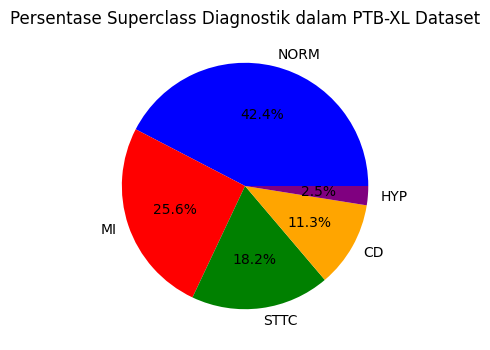

In [ ]:
# Visualisasi dengan pie chart (dengan ukuran lebih kecil)
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=["blue", "red", "green", "orange", "purple"])
plt.title("Percentage of Diagnostic superclass")
plt.show()

In [3]:
def load_ptbxl_signal(filepath):
    record = wfdb.rdrecord(filepath)
    return record.p_signal, record.sig_name  # Shape: (time_steps, 12) for 12-lead

# Load signals
signals = []
ids = []
labels = []
leads_names = []

for idx, row in filtered_df.iterrows():
    ecg_path = row['filename_hr']
    path = os.path.join(BASE_PATH, ecg_path)
    
    try:
        sig, lead_name = load_ptbxl_signal(path)
        signals.append(sig)
        leads_names.append(lead_name)
        ids.append(row['ecg_id'])
        labels.append(row['label'])
    except Exception as e:
        print(f"Error loading {path}: {e}")

In [4]:
X = np.array(signals)  # shape: (n_samples, 5000, 12)
y = np.array(labels)

print("Loaded ECG signals shape:", X.shape)
print("Binary labels shape:", y.shape)
print("Label counts:", np.unique(y, return_counts=True))

Loaded ECG signals shape: (0,)
Binary labels shape: (0,)
Label counts: (array([], dtype=float64), array([], dtype=int64))


# Data Preprocessing

In [ ]:
from scipy.signal import butter, filtfilt
import numpy as np

def highpass_filter(signal, fs=500, cutoff=0.5, order=3):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high')
    return filtfilt(b, a, signal, axis=0)

def normalize_signal(signal):
    return (signal - np.mean(signal, axis=0)) / np.std(signal, axis=0)

def preprocess_signal(signal):
    signal = highpass_filter(signal)
    signal = normalize_signal(signal)
    return signal

In [ ]:
preprocessed_signals = normalize_signal(signals)

# Plot Data

In [ ]:
import matplotlib.pyplot as plt

for j in range(4):
    plt.figure(figsize=(15, 8))
    # Plot first 6 leads
    for i in range(6):
        plt.subplot(6, 1, i + 1)
        # plt.plot(signals[j][:, i])
        plt.plot(preprocessed_signals[j][:, i])
        plt.title(f"Lead {leads_names[j][i]}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()